# Task-3 — Iris Flower Clustering Project

**Week 3: Unsupervised Learning + Model Evaluation**

This notebook applies K-Means clustering (k=3) to the Iris dataset, visualizes the clusters, compares predicted clusters with true species labels, and uses PCA to reduce the data to 2D.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, adjusted_rand_score, silhouette_score

## 2. Load and inspect the Iris dataset

In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="true_label")

print("Dataset shape:", X.shape)
display(X.head())
print("\nSpecies:", iris.target_names)

Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Species: ['setosa' 'versicolor' 'virginica']


## 3. Scale the features

K-Means is distance-based, so standardizing the features prevents variables with larger numeric scales from dominating the distance calculation.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("Feature means after scaling:", np.round(X_scaled.mean(axis=0), 3))
print("Feature standard deviations after scaling:", np.round(X_scaled.std(axis=0), 3))

Scaled data shape: (150, 4)
Feature means after scaling: [-0. -0. -0. -0.]
Feature standard deviations after scaling: [1. 1. 1. 1.]


## 4. Elbow method for choosing K

The elbow method compares K-Means inertia for different numbers of clusters.

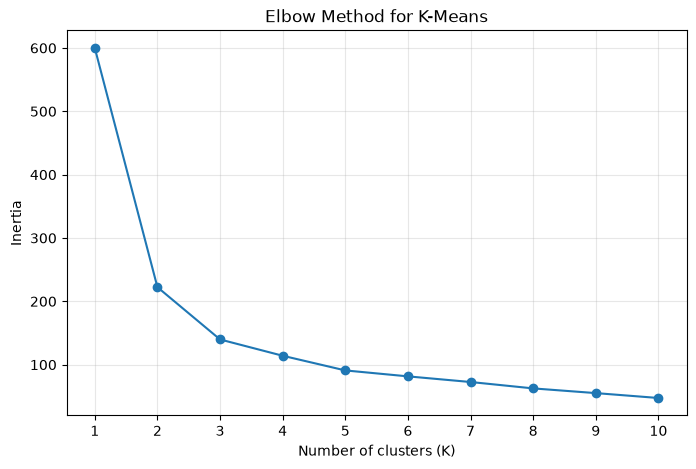

In [4]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

## 5. Apply K-Means with k=3

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nCluster centers (standardized feature space):")
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=iris.feature_names)
display(cluster_centers)

Cluster counts:
0    53
1    50
2    47
Name: count, dtype: int64

Cluster centers (standardized feature space):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.050220,-0.883376,0.347738,0.281527
1,-1.014579,0.853263,-1.304987,-1.254893
2,1.135970,0.088422,0.996155,1.017526


## 6. Visualize the K-Means clusters

The first two standardized features are used for a simple 2D visualization. PCA below provides a more informative 2D projection of all four features.

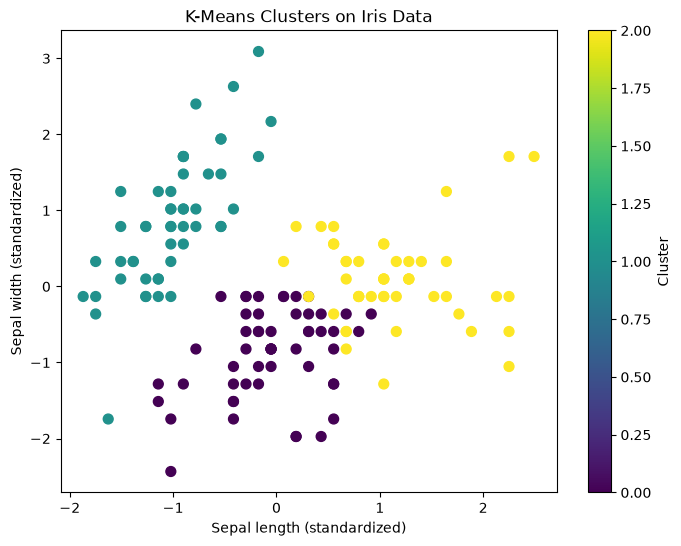

In [6]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=50
)
plt.xlabel("Sepal length (standardized)")
plt.ylabel("Sepal width (standardized)")
plt.title("K-Means Clusters on Iris Data")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 7. Compare predicted clusters with true labels

K-Means cluster numbers are arbitrary, so cluster `0`, `1`, and `2` do not automatically correspond to the species labels `setosa`, `versicolor`, and `virginica`. We therefore use a contingency table and the Adjusted Rand Index (ARI), which is unaffected by cluster-number permutation.

In [7]:
comparison = pd.crosstab(
    pd.Series(y, name="True species"),
    pd.Series(cluster_labels, name="Predicted cluster")
)
comparison.index = iris.target_names
display(comparison)

ari = adjusted_rand_score(y, cluster_labels)
silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Predicted cluster,0,1,2
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


Adjusted Rand Index (ARI): 0.6201
Silhouette Score: 0.4599


## 8. Apply PCA to reduce the dataset to 2D

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

print("PCA reduced shape:", X_pca.shape)
print("Explained variance ratio:")
for i, ratio in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"Total variance explained by 2 components: {explained_variance_ratio.sum():.4f} ({explained_variance_ratio.sum()*100:.2f}%)")

PCA reduced shape: (150, 2)
Explained variance ratio:
PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)
Total variance explained by 2 components: 0.9581 (95.81%)


## 9. Visualize clusters after PCA

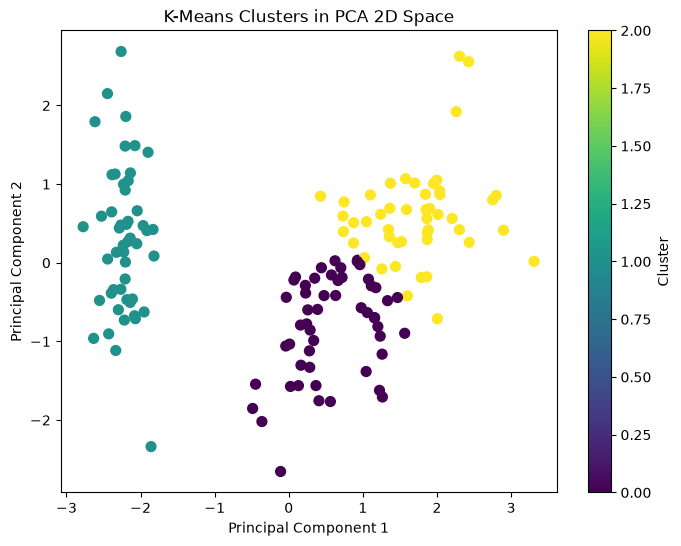

In [9]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=50
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in PCA 2D Space")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 10. Compare PCA visualization with true Iris species

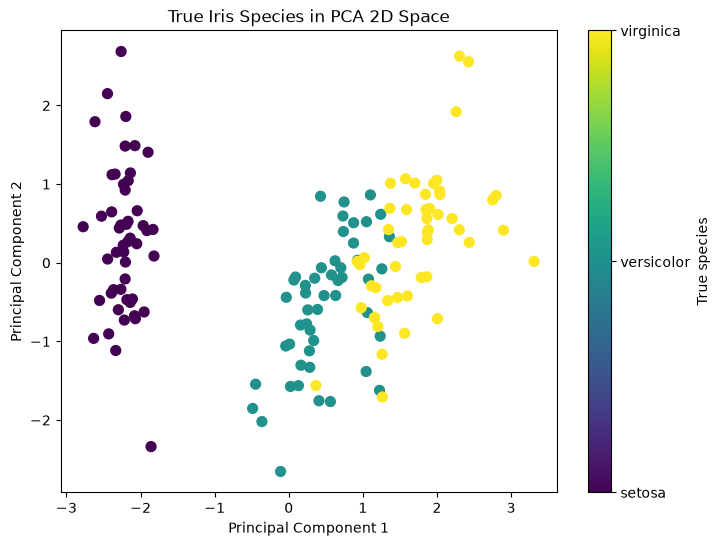

In [10]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=50
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("True Iris Species in PCA 2D Space")
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.set_label("True species")
cbar.ax.set_yticklabels(iris.target_names)
plt.show()

## 11. Conclusion

K-Means was successfully applied to the Iris dataset using **k=3**. The cluster centers were printed, the clusters were visualized, and the predicted clusters were compared with the true Iris species.

PCA reduced the four original features to two principal components, making the structure of the data easier to visualize. The explained variance ratios show how much information is retained by each component.

The comparison should be interpreted carefully because K-Means cluster numbers are arbitrary and do not directly represent the species names. The **Adjusted Rand Index (ARI)** provides a label-permutation-independent measure of how closely the discovered clusters match the known species groups.